# Categorical Data Plots with Seaborn

`import matplotlib.pyplot as plt` brings in Python's core plotting library, which most other plotting libraries (including seaborn) draw their charts on top of. `import seaborn as sns` brings in seaborn, a library built on matplotlib that makes it much easier to create nice-looking statistical charts with just one line of code.

**Usecase:** These two imports are needed at the start of the notebook so that every plotting function used later, like `sns.countplot`, `sns.barplot`, and `sns.boxplot`, is available to use.

In [69]:
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import numpy as np
import pandas as pd

warnings.filterwarnings('ignore')

## Categorical Data Plot Types

Now let's discuss using seaborn to plot categorical data! There are a few main plot types for this:

* **countplot** - Count of observations in each category
* **barplot** - Show point estimates and confidence intervals with bars
* **boxplot** - Show distributions with quartiles
* **violinplot** - Show distributions with kernel density estimation
* **stripplot** - Draw a scatterplot where one variable is categorical
* **swarmplot** - Draw a categorical scatterplot with non-overlapping points

Let's go through examples of each!

## Loading the Dataset

`sns.load_dataset("tips")` loads a small built-in sample dataset that ships with seaborn, so you don't need to go find and load your own CSV file to practice with. Here it loads the classic "tips" dataset, which has one row per restaurant bill with columns like `total_bill`, `tip`, `sex`, `smoker`, `day`, `time`, and `size`.

**Usecase:** This gives us the actual data used for every categorical plot in this notebook, letting us look at things like how tips or bills change depending on `day`, `sex`, or `smoker` status.

In [70]:
df = sns.load_dataset("tips")
print("Dataset shape:", df.shape)
df.head()

Dataset shape: (244, 7)


,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


## Count Plot

`sns.countplot()` simply counts how many rows fall into each category and draws a bar for each count, so it's basically a bar chart of frequencies rather than of some other measured value. Passing a `hue` splits each bar further into smaller bars based on a second category.

**Usecase:** Here it counts how many customers are Male vs Female (`sex`), and within each of those, splits the counts further by whether they were a `smoker` or not, so you can see the raw counts for every combination.

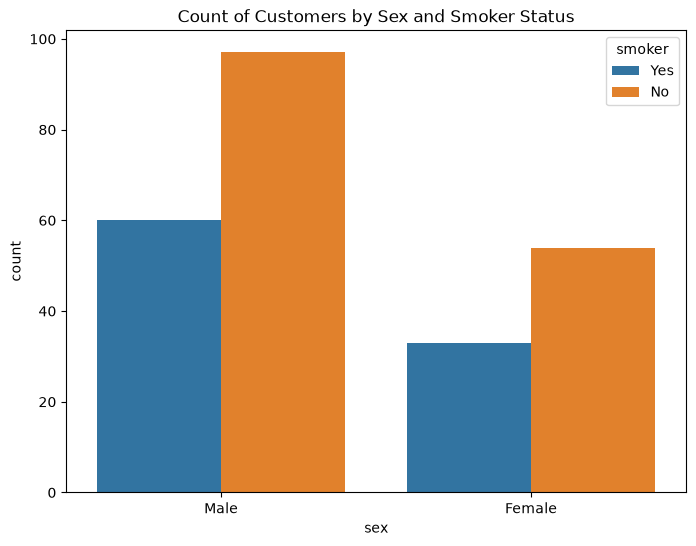

In [71]:
plt.figure(figsize=(8, 6))
sns.countplot(x='sex', hue='smoker', data=df)
plt.title('Count of Customers by Sex and Smoker Status')
plt.show()

## Bar Plot

`sns.barplot()` draws one bar per category showing an aggregated value of a numeric column for that category (by default the average), along with a small vertical line on top of the bar showing the uncertainty around that value. Unlike `countplot`, which just counts rows, `barplot` summarizes an actual numeric column.

**Usecase:** Here it shows the average `total_bill` for each `sex`, so you can quickly compare whether one group tends to spend more on average than the other.

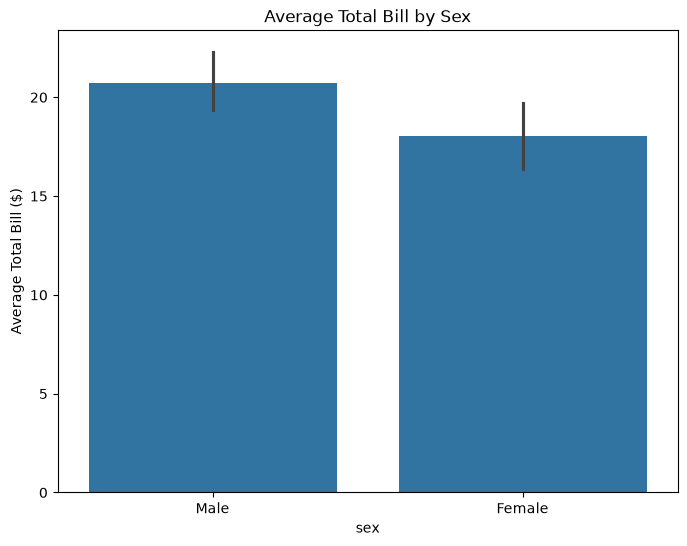

In [72]:
plt.figure(figsize=(8, 6))
sns.barplot(x='sex', y='total_bill', data=df)
plt.title('Average Total Bill by Sex')
plt.ylabel('Average Total Bill ($)')
plt.show()

### Bar Plot with Different Estimators

You can change the estimator object to your own function, that converts a vector to a scalar:

- Mean (default): np.mean
- Median: np.median
- Sum: np.sum
- Count: len (to count the number of observations)
- Standard Deviation: np.std
- Minimum: np.min
- Maximum: np.max

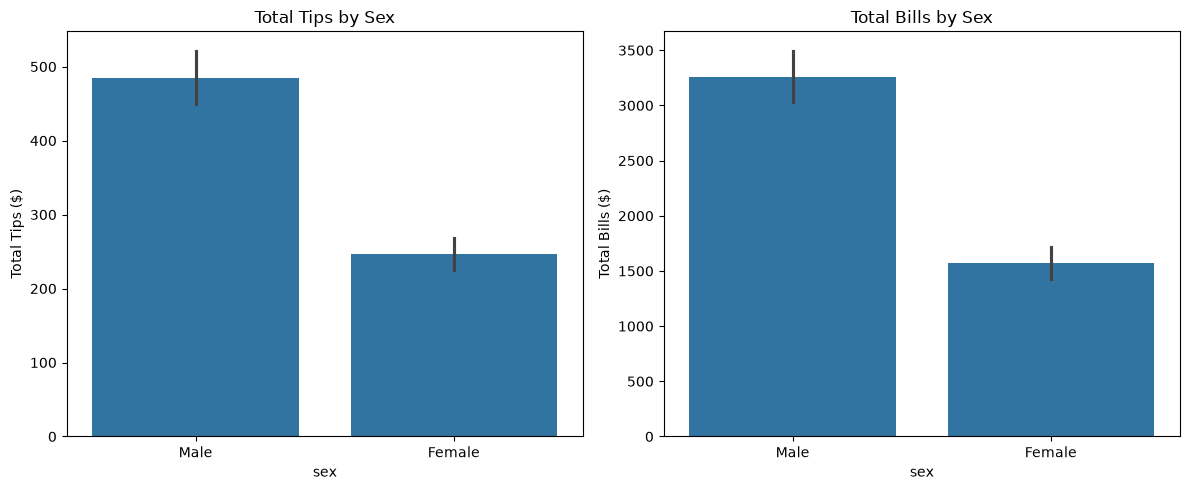

In [73]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.barplot(x='sex', y='tip', estimator=np.sum, data=df)
plt.title('Total Tips by Sex')
plt.ylabel('Total Tips ($)')

plt.subplot(1, 2, 2)
sns.barplot(x='sex', y='total_bill', estimator=np.sum, data=df)
plt.title('Total Bills by Sex')
plt.ylabel('Total Bills ($)')

plt.tight_layout()
plt.show()

## Box Plot

`sns.boxplot()` draws a box for each category showing the spread of a numeric column: the middle line is the median, the box covers the middle 50% of the values, the whiskers stretch out to the typical range of the rest, and any dots past that are treated as outliers. The `palette` argument just controls what colors are used for each box.

**Usecase:** Here it shows how `tip` amounts are spread out for each `day` of the week, so you can see not just the typical tip per day but also how much tips vary and whether some days have unusually high or low outlier tips.

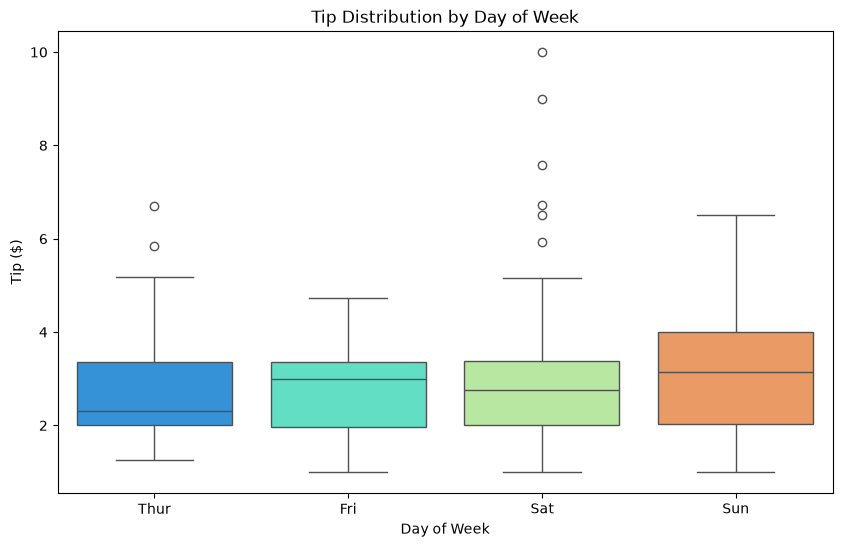

In [74]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='day', y='tip', data=df, palette='rainbow')
plt.title('Tip Distribution by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Tip ($)')
plt.show()

## Violin Plot

Boxplots and violinplots are used to show the distribution of categorical data. A violin plot shows the distribution of quantitative data across several levels of one (or more) categorical variables such that those distributions can be compared. Unlike a box plot, in which all of the plot components correspond to actual datapoints, the violin plot features a kernel density estimation of the underlying distribution.

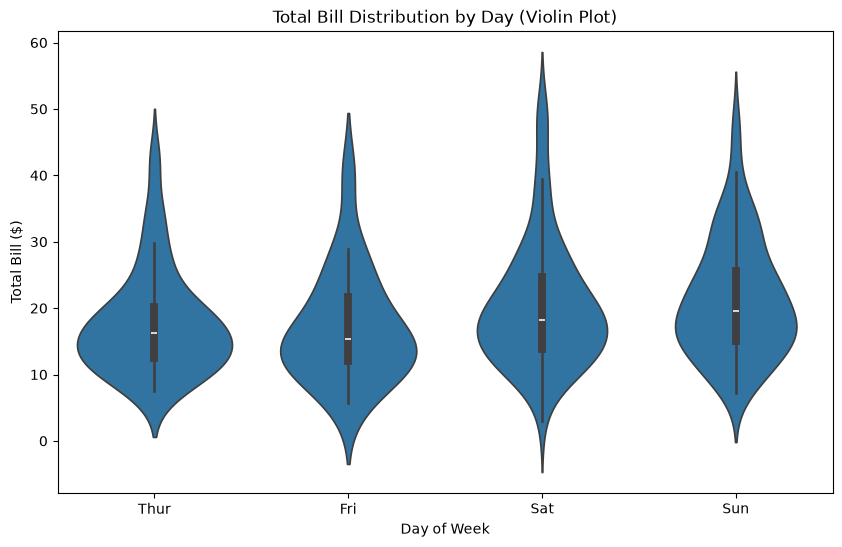

In [75]:
plt.figure(figsize=(10, 6))
sns.violinplot(x='day', y='total_bill', data=df)
plt.title('Total Bill Distribution by Day (Violin Plot)')
plt.xlabel('Day of Week')
plt.ylabel('Total Bill ($)')
plt.show()

## Strip Plot and Swarm Plot

The stripplot will draw a scatterplot where one variable is categorical. A strip plot can be drawn on its own, but it is also a good complement to a box or violin plot in cases where you want to show all observations along with some representation of the underlying distribution.

The swarmplot is similar to stripplot(), but the points are adjusted (only along the categorical axis) so that they don't overlap. This gives a better representation of the distribution of values, although it does not scale as well to large numbers of observations (both in terms of the ability to show all the points and in terms of the computation needed to arrange them).

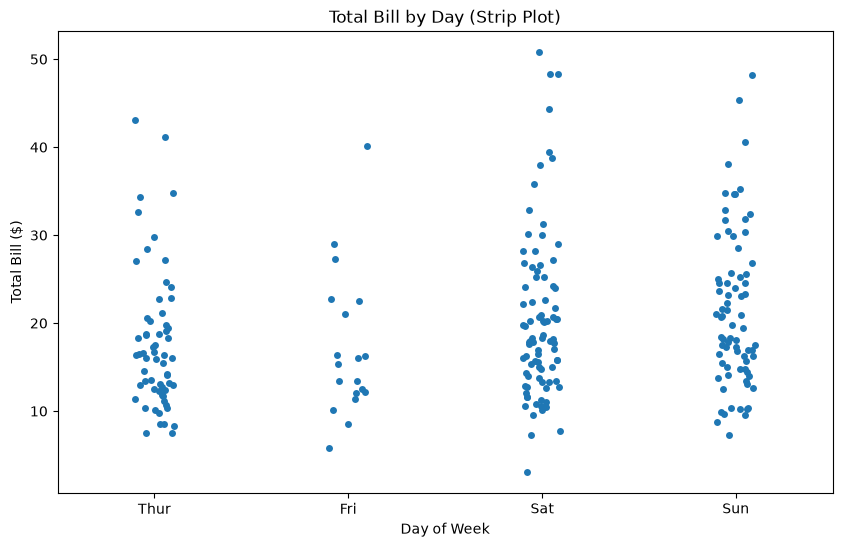

In [76]:
plt.figure(figsize=(10, 6))
sns.stripplot(x='day', y='total_bill', data=df)
plt.title('Total Bill by Day (Strip Plot)')
plt.xlabel('Day of Week')
plt.ylabel('Total Bill ($)')
plt.show()

### Swarm Plot

`sns.swarmplot()` plots every single data point as its own dot along the categorical axis, but nudges overlapping dots sideways so none of them land exactly on top of each other. This means you can see every individual observation, instead of just a summary like a mean or median.

**Usecase:** Here it plots every individual `total_bill` value for each `day`, so rather than hiding the data behind an average, you can see the actual spread and clustering of individual bills on each day.

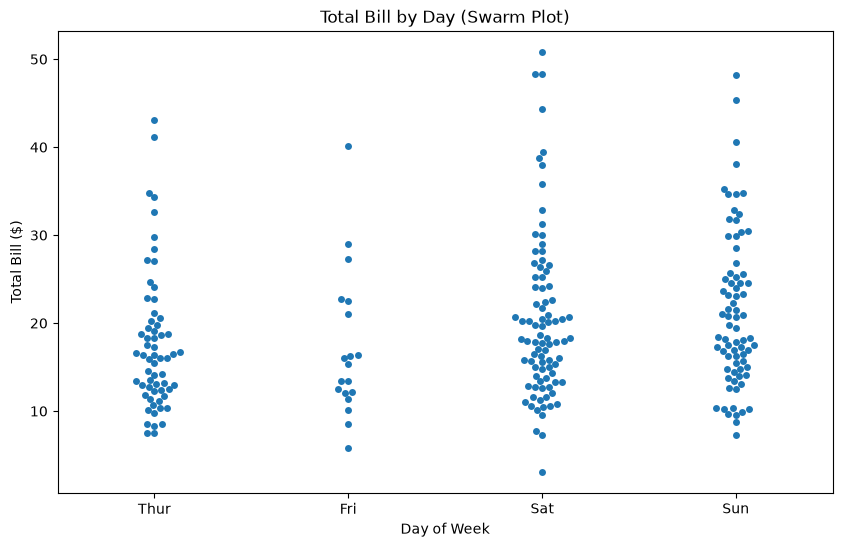

In [77]:
plt.figure(figsize=(10, 6))
sns.swarmplot(x='day', y='total_bill', data=df)
plt.title('Total Bill by Day (Swarm Plot)')
plt.xlabel('Day of Week')
plt.ylabel('Total Bill ($)')
plt.show()

### Combining Violin and Swarm Plots

This cell draws two plots on top of each other on the same axes. `sns.violinplot()` first draws the smoothed shape of the distribution (like a boxplot, but showing the full shape of the data mirrored on both sides so it looks like a violin), and then `sns.swarmplot()` draws every individual data point as a dot on top of that shape.

**Usecase:** Here it combines both views for `tip` by `day`: the violin shape shows the overall distribution of tips on each day, while the swarm dots layered on top show exactly where the real individual tip values fall within that shape.

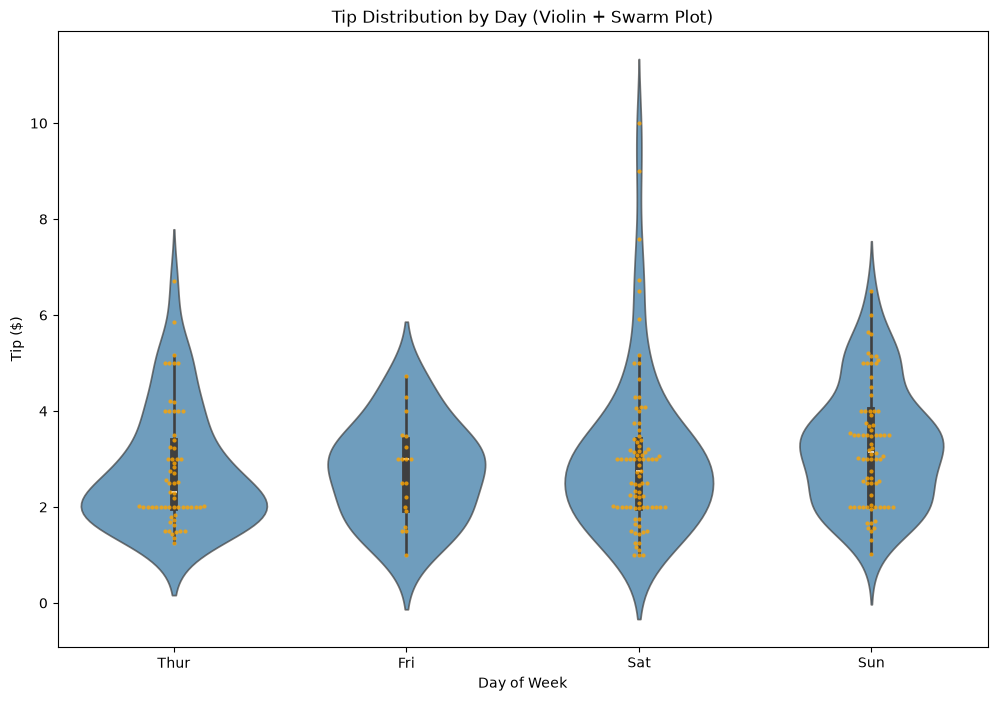

In [82]:
plt.figure(figsize=(12, 8))
sns.violinplot(x='day', y='tip', data=df, alpha=0.7)
sns.swarmplot(x='day', y='tip', data=df, color='orange', alpha=0.8, size=3)
plt.title('Tip Distribution by Day (Violin + Swarm Plot)')
plt.xlabel('Day of Week')
plt.ylabel('Tip ($)')
plt.show()

## Additional Examples with Different Variables

Let's explore some additional categorical plot examples using different combinations of variables.

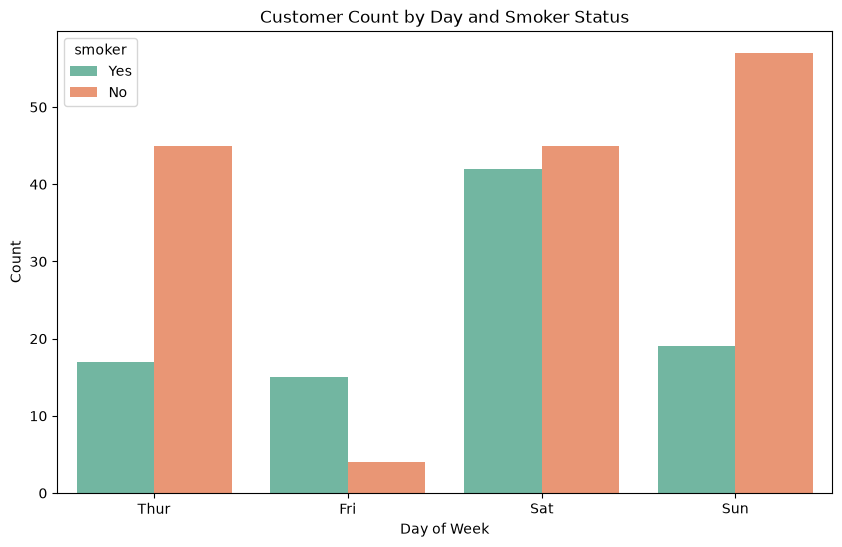

In [79]:
# Count plot by day with smoker hue
plt.figure(figsize=(10, 6))
sns.countplot(x='day', hue='smoker', data=df, palette='Set2')
plt.title('Customer Count by Day and Smoker Status')
plt.xlabel('Day of Week')
plt.ylabel('Count')
plt.show()

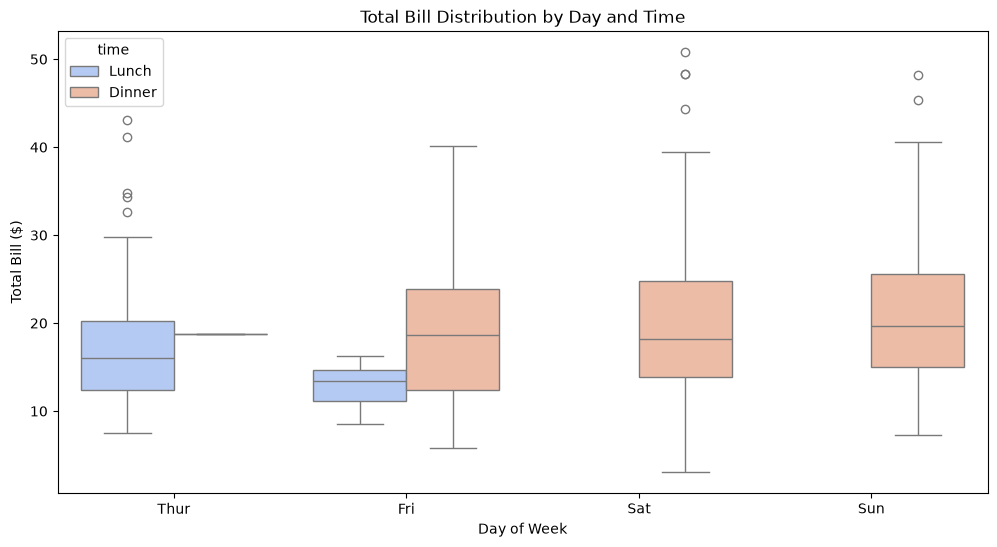

In [80]:
# Box plot with multiple categorical variables
plt.figure(figsize=(12, 6))
sns.boxplot(x='day', y='total_bill', hue='time', data=df, palette='coolwarm')
plt.title('Total Bill Distribution by Day and Time')
plt.xlabel('Day of Week')
plt.ylabel('Total Bill ($)')
plt.show()

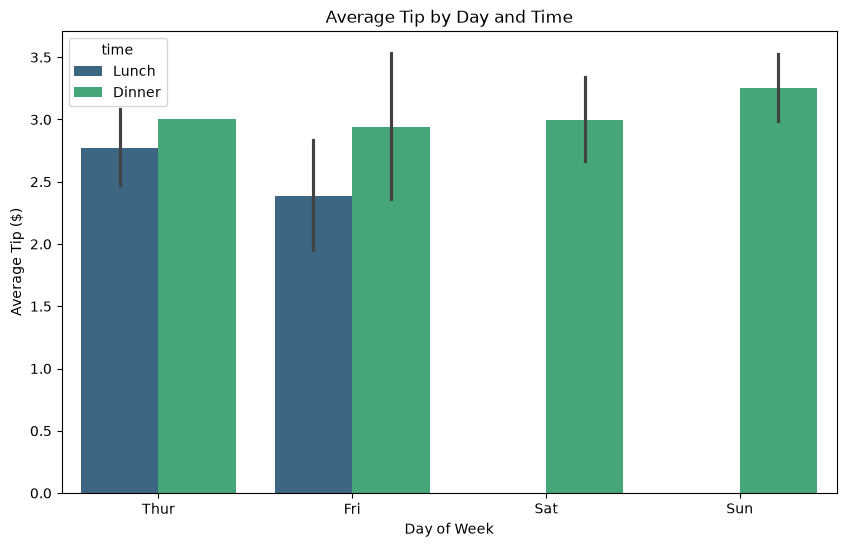

In [81]:
# Bar plot showing average tip by day and time
plt.figure(figsize=(10, 6))
sns.barplot(x='day', y='tip', hue='time', data=df, palette='viridis')
plt.title('Average Tip by Day and Time')
plt.xlabel('Day of Week')
plt.ylabel('Average Tip ($)')
plt.show()

## Summary

In this notebook, we explored various categorical plots using seaborn:

1. **Count Plot**: Shows frequency of categories
   - Simple counts by category
   - Grouped counts with hue parameter

2. **Bar Plot**: Shows statistical estimates (mean, sum, etc.) by category
   - Default shows mean with confidence intervals
   - Can use different estimators (sum, median, etc.)

3. **Box Plot**: Shows distribution quartiles and outliers
   - Median, IQR, and outliers clearly visible
   - Good for comparing distributions across categories

4. **Violin Plot**: Shows full distribution shape
   - Kernel density estimation of the distribution
   - More informative than box plots for distribution shape

5. **Strip Plot**: Shows all individual data points
   - Raw data points along categorical axis
   - Can show overlapping points

6. **Swarm Plot**: Shows all data points without overlap
   - Better visualization of point density
   - Computationally intensive for large datasets

These plots are essential for exploring relationships between categorical and numerical variables in your data!